# AIM · 4주차 실습
## Attention ② 작은 Transformer 만들기

**대상:** Python·PyTorch 기초 이수자 / **권장:** Google Colab Python 3, GPU 선택 가능.

3주차 attention과 문자 코퍼스를 독립적으로 다시 정의해 이전 실행 상태 없이 시작할 수 있다. 기본 실습은 짧은 문맥과 작은 모델을 사용한다. 대형 모델 학습이나 챗봇 품질을 목표로 하지 않는다.

### 학습 목표
- multi-head attention과 pre-norm block을 구현한다.
- 소형 decoder 언어 모델을 학습하고 sampling을 비교한다.
- 데이터 누출·인과성·평가 조건을 검사한다.

### 실행 방법
1. Colab에서 `파일 → 노트북 업로드`로 이 파일을 엽니다.
2. GPU를 사용할 경우 `런타임 → 런타임 유형 변경`에서 GPU를 선택합니다.
3. 위에서 아래로 셀을 실행합니다. 이전 주차 파일이나 별도 Python 모듈은 필요 없습니다.
4. Colab 기본 torch·torchvision을 우선 사용합니다. import가 실패하면 새 런타임에서 시작하세요.
   로컬 환경은 루트 `환경설정.md`를 참고하세요. 데이터 최초 다운로드에는 인터넷이 필요합니다.
5. 학습이 길면 `TRAIN_N`, `EPOCHS` 또는 `STEPS`를 줄입니다. 작은 실험의 품질은 보장되지 않습니다.

**시간 운영:** 실습 셀 번호가 아니라 아래 § 구간으로 진행합니다. 준비·다운로드는 수업 시작에,
핵심 실행은 50–75분에, 관찰 답변은 75–85분에 수행합니다. 심화와 자율 과제는 수업 밖에서 진행합니다.

**재현성:** 고정 seed도 다른 GPU·라이브러리 버전의 완전히 같은 수치를 보장하지 않습니다.
실제 출력과 예측을 구분해 기록하세요. `outputs/`는 현재 실행 폴더에 생성됩니다.

## §1 · 환경 확인

첫 실행에서 버전과 device를 확인합니다. CPU도 지원하며 설치가 필요한 경우 환경설정 문서를 먼저 읽습니다.

In [1]:
import os, sys, math, random, copy, time, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from IPython.display import display

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# QUICK=True: 수업용 일부 데이터. False: 데이터/학습 예산 확대.
QUICK = True
# 검증 제작자용 축소 모드. 수강생은 설정할 필요가 없습니다.
SMOKE = os.environ.get('AIM_SMOKE', '0') == '1'
DATA_ROOT = Path(os.environ.get('AIM_DATA_ROOT', './data'))
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
torch.set_num_threads(min(4, os.cpu_count() or 1))

def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_all()
print('Python', sys.version.split()[0], '| torch', torch.__version__,
      '| torchvision', torchvision.__version__, '| device', DEVICE)
print('QUICK:', QUICK, '| SMOKE:', SMOKE, '| data:', DATA_ROOT.resolve())

def image_grid(images, titles=None, cols=8, title='', normalized=False):
    images = images.detach().cpu()
    if normalized: images = (images * .5 + .5).clamp(0, 1)
    n = len(images); rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.35, rows*1.55), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            im = images[i]
            ax.imshow(im.squeeze(0) if im.shape[0]==1 else im.permute(1,2,0),
                      cmap='gray', vmin=0, vmax=1)
            if titles is not None: ax.set_title(str(titles[i]), fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    return fig

def num_params(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)

def cpu_state(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

Python 3.13.9 | torch 2.14.0+cpu | torchvision 0.29.0+cpu | device cpu
QUICK: True | SMOKE: False | data: D:\AIM\.study-data


In [2]:
BATCH = 8 if SMOKE else 32
CONTEXT = 16 if SMOKE else 32
STEPS = 6 if SMOKE else (240 if QUICK else 1500)

## §2 · 코퍼스, vocabulary, next-token target

수업용으로 새로 작성한 조합 문장을 사용합니다. 문장 단위로 먼저 분할하고 split 내부에서만 window를 만듭니다. exact 문장은 분리되지만 문법과 어휘는 공유됩니다. 실제 자연어 능력을 평가하는 자료는 아닙니다.

In [3]:
# 외부 저작물을 쓰지 않은 교육용 조합 문장. exact 문장 중복 없이 먼저 분할.
subjects=['the cat','the dog','a student','the teacher','a robot','my friend','the artist','a scientist']
verbs=['reads','finds','draws','builds','likes','studies']
objects=['a book','a small map','the new model','a red house','a quiet room','the blue box']
places=['in the lab','after class','near the river','every morning']
sentences=[f'{s} {v} {o} {p}.\n' for s in subjects for v in verbs for o in objects for p in places]
rng=random.Random(SEED); rng.shuffle(sentences)
n=len(sentences); a=int(.8*n); b=int(.9*n)
parts={'train':sentences[:a],'val':sentences[a:b],'test':sentences[b:]}
assert not (set(parts['train']) & set(parts['val']))
assert not (set(parts['train']) & set(parts['test']))
assert not (set(parts['val']) & set(parts['test']))
itos=['<UNK>']+sorted(set(''.join(parts['train'])))
stoi={c:i for i,c in enumerate(itos)}; VOCAB=len(itos)
def encode(text): return [stoi.get(c,0) for c in text]
def decode(ids): return ''.join(itos[int(i)] if int(i)!=0 else '�' for i in ids)
tokens={k:torch.tensor(encode(''.join(v)),dtype=torch.long) for k,v in parts.items()}
print('sentences:',{k:len(v) for k,v in parts.items()},'| vocab:',VOCAB)
print('tokens:',{k:len(v) for k,v in tokens.items()})
print('UNK fractions:',{k:(v==0).float().mean().item() for k,v in tokens.items()})
print('train example:',parts['train'][0])

def lm_batch(split='train',batch=BATCH,context=CONTEXT):
    data=tokens[split]; starts=torch.randint(len(data)-context,(batch,))
    x=torch.stack([data[i:i+context] for i in starts])
    y=torch.stack([data[i+1:i+context+1] for i in starts])
    return x.to(DEVICE),y.to(DEVICE)

x_example,y_example=lm_batch(batch=1)
print('input :',repr(decode(x_example[0])))
print('target:',repr(decode(y_example[0])))
assert torch.equal(x_example[:,1:],y_example[:,:-1])

sentences: {'train': 921, 'val': 115, 'test': 116} | vocab: 28
tokens: {'train': 38852, 'val': 4852, 'test': 4920}
UNK fractions: {'train': 0.0, 'val': 0.0, 'test': 0.0}
train example: the dog reads a red house after class.

input : ' after class.\na robot draws a sm'
target: 'after class.\na robot draws a sma'


## §3 · attention 직접 구현

`scaled_attention`은 True인 위치를 차단하는 `blocked`를 사용합니다. softmax는 key 축에 적용합니다.

In [4]:
def scaled_attention(q,k,v,causal=True):
    scores=q @ k.transpose(-2,-1) / math.sqrt(q.size(-1))
    if causal:
        blocked=torch.ones(q.size(-2),k.size(-2),device=q.device,dtype=torch.bool).triu(1)
        scores=scores.masked_fill(blocked,float('-inf'))
    weights=scores.softmax(dim=-1)
    return weights @ v,weights

class BigramLM(nn.Module):
    def __init__(self):
        super().__init__(); self.table=nn.Embedding(VOCAB,VOCAB)
    def forward(self,ids): return self.table(ids)

class SingleHeadLM(nn.Module):
    def __init__(self,d=64):
        super().__init__()
        self.token=nn.Embedding(VOCAB,d); self.position=nn.Embedding(CONTEXT,d)
        self.q=nn.Linear(d,d,bias=False); self.k=nn.Linear(d,d,bias=False); self.v=nn.Linear(d,d,bias=False)
        self.head=nn.Linear(d,VOCAB)
    def forward(self,ids,return_attention=False):
        h=self.token(ids)+self.position(torch.arange(ids.size(1),device=ids.device))
        out,a=scaled_attention(self.q(h),self.k(h),self.v(h))
        logits=self.head(out)
        return (logits,a) if return_attention else logits

## §3-2 · multi-head와 Transformer block

pre-norm, residual, FFN과 헤드 reshape를 추적합니다. 이 모델은 원 논문의 encoder-decoder 전체 재현이 아닙니다.

In [5]:
class CausalMHA(nn.Module):
    def __init__(self,d=64,heads=4,dropout=.1):
        super().__init__(); assert d % heads == 0
        self.d=d; self.heads=heads
        self.qkv=nn.Linear(d,3*d); self.out=nn.Linear(d,d)
        self.attn_drop=nn.Dropout(dropout); self.out_drop=nn.Dropout(dropout)
    def forward(self,x):
        b,t,d=x.shape
        q,k,v=self.qkv(x).chunk(3,dim=-1)
        q,k,v=[u.reshape(b,t,self.heads,d//self.heads).transpose(1,2) for u in (q,k,v)]
        scores=q @ k.transpose(-2,-1)/math.sqrt(d//self.heads)
        blocked=torch.ones(t,t,device=x.device,dtype=torch.bool).triu(1)
        a=scores.masked_fill(blocked,float('-inf')).softmax(-1)
        out=self.attn_drop(a) @ v
        out=out.transpose(1,2).contiguous().view(b,t,d)
        return self.out_drop(self.out(out))

class TransformerBlock(nn.Module):
    def __init__(self,d=64,heads=4,dropout=.1):
        super().__init__()
        self.ln1=nn.LayerNorm(d); self.ln2=nn.LayerNorm(d)
        self.attn=CausalMHA(d,heads,dropout)
        self.ffn=nn.Sequential(nn.Linear(d,4*d),nn.GELU(),nn.Linear(4*d,d),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.ln1(x))
        return x+self.ffn(self.ln2(x))

class TinyTransformer(nn.Module):
    def __init__(self,d=64,heads=4,layers=2,dropout=.1):
        super().__init__()
        self.config=dict(d=d,heads=heads,layers=layers,dropout=dropout)
        self.token=nn.Embedding(VOCAB,d); self.position=nn.Embedding(CONTEXT,d)
        self.blocks=nn.Sequential(*[TransformerBlock(d,heads,dropout) for _ in range(layers)])
        self.norm=nn.LayerNorm(d); self.head=nn.Linear(d,VOCAB)
    def forward(self,ids):
        assert ids.size(1)<=CONTEXT
        x=self.token(ids)+self.position(torch.arange(ids.size(1),device=ids.device))
        return self.head(self.norm(self.blocks(x)))

## §4 · 언어 모델 학습과 생성 함수

평가는 고정 window의 token CE를 집계합니다. 마지막 불완전 window는 제외합니다. 생성은 매번 마지막 CONTEXT 문자를 다시 계산합니다.

In [6]:
@torch.no_grad()
def lm_eval(model,split='val'):
    was_training=model.training; model.eval(); total=count=0
    data=tokens[split]
    # 고정 연속 window: 평가 target을 중복 계산하지 않으며 남는 마지막 불완전 window는 제외.
    for start in range(0,len(data)-CONTEXT,CONTEXT*BATCH):
        starts=range(start,min(start+CONTEXT*BATCH,len(data)-CONTEXT),CONTEXT)
        x=torch.stack([data[i:i+CONTEXT] for i in starts]).to(DEVICE)
        y=torch.stack([data[i+1:i+CONTEXT+1] for i in starts]).to(DEVICE)
        logits=model(x)
        total+=F.cross_entropy(logits.reshape(-1,VOCAB),y.reshape(-1),reduction='sum').item()
        count+=y.numel()
    model.train(was_training)
    return total/count

def fit_lm(factory,steps=STEPS):
    seed_all(); model=factory().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=3e-3,weight_decay=.01)
    history=[]; best=float('inf'); state=None; start=time.perf_counter()
    for step in range(1,steps+1):
        model.train(); x,y=lm_batch(); opt.zero_grad(set_to_none=True)
        loss=F.cross_entropy(model(x).reshape(-1,VOCAB),y.reshape(-1))
        assert torch.isfinite(loss)
        loss.backward(); norm=nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        if step==1 or step%max(1,steps//5)==0 or step==steps:
            val=lm_eval(model)
            history.append(dict(step=step,train_ce=loss.item(),val_ce=val,grad_norm=float(norm)))
            if val<best: best=val; state=cpu_state(model)
            print(f'step {step}: train={loss.item():.3f} val={val:.3f}')
    model.load_state_dict(state); model.eval()
    return model,history,time.perf_counter()-start

@torch.no_grad()
def generate(model,prompt='the ',new_tokens=120,temperature=1.0,top_k=None,greedy=False,seed=123):
    assert temperature>0 and len(prompt)>0
    seed_all(seed); model.eval()
    ids=torch.tensor([encode(prompt)],device=DEVICE)
    for _ in range(new_tokens):
        logits=model(ids[:,-CONTEXT:])[:,-1,:]/temperature
        if top_k is not None:
            k=max(1,min(int(top_k),VOCAB)); values,index=logits.topk(k)
            logits=torch.full_like(logits,float('-inf')).scatter(1,index,values)
        nxt=logits.argmax(-1,keepdim=True) if greedy else torch.multinomial(logits.softmax(-1),1)
        ids=torch.cat([ids,nxt],dim=1)
    return decode(ids[0])

def assert_causal(model):
    model.eval(); x,_=lm_batch(batch=2); changed=x.clone(); cut=CONTEXT//2
    changed[:,cut:]=(changed[:,cut:]+1)%VOCAB
    with torch.no_grad():
        a=model(x)[:,:cut]; b=model(changed)[:,:cut]
    torch.testing.assert_close(a,b,atol=1e-5,rtol=1e-5)
    print('PASS: changing future tokens does not change earlier logits')

def plot_lm(histories):
    for name,h in histories.items():
        plt.plot([r['step'] for r in h],[r['val_ce'] for r in h],label=name+' val')
        plt.plot([r['step'] for r in h],[r['train_ce'] for r in h],'--',label=name+' train batch')
    plt.xlabel('step'); plt.ylabel('cross entropy'); plt.legend(); plt.grid(alpha=.2); plt.show()

## §3-검사 · shape와 causal 불변성

eval 상태에서 미래 토큰만 변경해 과거 logits가 같은지 확인합니다.

In [7]:
m=TinyTransformer().to(DEVICE); x,y=lm_batch(batch=2)
assert m(x).shape==(2,CONTEXT,VOCAB)
assert_causal(m)
print('params:',num_params(m),'D=64 / heads=4 / head_dim=16')

PASS: changing future tokens does not change earlier logits
params: 105756 D=64 / heads=4 / head_dim=16


**관찰·토론**

헤드 수를 8로 바꾸면 head 차원과 QKV projection 파라미터 수는 어떻게 되나요?

## §4-실행 · Transformer 학습

train CE는 기록 시점의 한 배치, val CE는 고정 평가 window 전체 평균입니다.

step 1: train=3.473 val=3.233
step 48: train=1.536 val=1.487
step 96: train=0.836 val=0.691
step 144: train=0.469 val=0.359
step 192: train=0.357 val=0.291
step 240: train=0.325 val=0.271


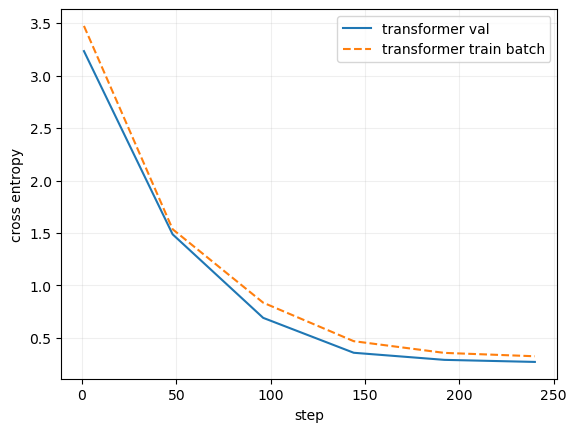

seconds: 3.067033499944955 val CE: 0.27126738567225983 test CE: 0.27355841717688867 test PPL: 1.314634154184893
PASS: changing future tokens does not change earlier logits


In [8]:
lm,history,seconds=fit_lm(TinyTransformer)
plot_lm({'transformer':history})
val_ce=lm_eval(lm); test_ce=lm_eval(lm,'test')
print('seconds:',seconds,'val CE:',val_ce,'test CE:',test_ce,'test PPL:',math.exp(test_ce))
assert_causal(lm)

**관찰·토론**

곡선의 train 값이 val 값보다 높거나 낮은 경우를 무조건 과적합이라고 부를 수 있나요? dropout과 측정 표본 차이도 고려하세요.

## §5 · 네 가지 생성 방식

모든 조건은 같은 학습된 가중치와 prompt를 사용합니다. sampling은 재학습이 아닙니다.

In [9]:
settings=[('greedy',dict(greedy=True)),('temperature .7',dict(temperature=.7)),
          ('temperature 1.3',dict(temperature=1.3)),('top-k 5',dict(top_k=5))]
samples={name:generate(lm,**kwargs) for name,kwargs in settings}
for name,text in samples.items(): print('\n'+name+'\n'+text)
(OUT/'generated_samples.json').write_text(json.dumps(samples,indent=2))


greedy
the lab.
the teacher builds a red house every morning.
the teacher builds a small map after class.
the cat builds a small ma

temperature .7
the lab.
the teacher builds a book near the river.
the cat likes a red house enear the clab.
the teacher finds a small map n

temperature 1.3
the lab.
my friend likes tes the blue box enear the river.
austudent reads a red house in the lab.
the artist likes the new 

top-k 5
the lab.
the teacher builds a book near the river.
awstudent likes a red house every morning.
a student draws the new model 


592

**관찰·토론**

반복되는 문자열 길이, 잘못된 철자, 문장 마침표 사용을 비교하세요. 한 샘플만 보고 설정을 고르지 마세요.

## §6 · 저장·복원 검증

자신이 만든 checkpoint만 불러옵니다. vocabulary와 구조 설정을 함께 보존합니다.

In [10]:
checkpoint={'state_dict':cpu_state(lm),'config':lm.config,'itos':itos,'context':CONTEXT,'seed':SEED}
torch.save(checkpoint,OUT/'tiny_transformer.pt')
loaded=torch.load(OUT/'tiny_transformer.pt',map_location='cpu',weights_only=True)
assert loaded['itos']==itos and loaded['context']==CONTEXT
restored=TinyTransformer(**loaded['config']).to(DEVICE)
restored.load_state_dict(loaded['state_dict']); restored.eval(); lm.eval()
x,_=lm_batch(batch=2)
with torch.no_grad(): torch.testing.assert_close(restored(x),lm(x))
print('PASS: checkpoint round-trip logits')

PASS: checkpoint round-trip logits


## 실험 기록표 · 직접 작성

| 항목 | 기록 |
|---|---|
| 가설 / 바꿀 변수 | |
| 고정한 분할·seed·학습 예산 | |
| 실제 관측 지표와 그림 | |
| 예상과 다른 점 | |
| 가능한 이유 2가지 | |
| 한계와 다음 실험 | |

## 출구 확인

PPT 출구 퀴즈에 답한 뒤, 오늘 모델의 **입력 → 중간 표현 → 출력 → loss → 평가**를 다섯 줄로 적으세요.
자율 과제는 `homework_optional.ipynb`, 리더 참고 구현은 `leader_solution.ipynb`입니다.

## 출처 및 추가 읽기

- [Attention Is All You Need · Vaswani et al.](https://arxiv.org/abs/1706.03762)
- [Scaled Dot Product Attention · 공식 API](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html)
- [CrossEntropyLoss · 공식 API](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

모든 설명용 코드와 도식은 수업용으로 새로 작성했습니다. 외부 원문 코드를 그대로 복제하지 않았습니다.